<a href="https://colab.research.google.com/github/Raffy0-1/DHC-Phase-2-ML-Task_2/blob/main/End_to_End_ML_Pipeline.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##  Objective
Build a production-ready, reusable machine learning pipeline to predict
customer churn using the IBM Telco dataset — following real-world ML
engineering practices from raw data to exported model.

#Phase 1 — Setup + Load Data

Mounting Google Drive

In [1]:
from google.colab import drive
drive.mount('/content/drive')

# dedicated project folder
import os
PROJECT_PATH = '/content/drive/MyDrive/telco_churn_pipeline'
os.makedirs(PROJECT_PATH, exist_ok=True)

print(f"Drive mounted. Project folder ready at: {PROJECT_PATH}")

Mounted at /content/drive
Drive mounted. Project folder ready at: /content/drive/MyDrive/telco_churn_pipeline


Imports

In [2]:
# If something isn't installed, pip install it here.

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Sklearn
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (classification_report, confusion_matrix,
                             roc_auc_score, roc_curve, ConfusionMatrixDisplay)

# For saving our pipeline
import joblib
import warnings
warnings.filterwarnings('ignore')

# Reproducibility — every random operation uses seed 42
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print("All libraries imported successfully")

All libraries imported successfully


TELCO dataset Dowwnload

In [3]:
# The Telco Customer Churn dataset is a classic — IBM released it publicly.
# We'll download it directly from a reliable source.

import urllib.request

DATASET_URL = "https://raw.githubusercontent.com/IBM/telco-customer-churn-on-icp4d/master/data/Telco-Customer-Churn.csv"
DATASET_PATH = f"{PROJECT_PATH}/telco_churn.csv"

# Download only if not already saved (saves time on runtime restarts)
if not os.path.exists(DATASET_PATH):
    urllib.request.urlretrieve(DATASET_URL, DATASET_PATH)
    print(f"Dataset downloaded and saved to Drive: {DATASET_PATH}")
else:
    print(f"Dataset already exists on Drive. Loading from cache.")

df = pd.read_csv(DATASET_PATH)
print(f"\nShape: {df.shape[0]} rows × {df.shape[1]} columns")
df.head()

Dataset already exists on Drive. Loading from cache.

Shape: 7043 rows × 21 columns


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


Looking into Data

In [4]:
# Before ANY machine learning, you must understand your dataset.
# This is not optional — skipping this is how bad models get built.

print("\nBASIC INFO")
print(df.info())


print("\nMISSING VALUES")

print(df.isnull().sum())


print("\nTARGET VARIABLE DISTRIBUTION")

print(df['Churn'].value_counts())
print(f"\nChurn rate: {df['Churn'].value_counts(normalize=True)['Yes']:.1%}")


BASIC INFO
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-nul

#Phase 2 — Data Cleaning + EDA

Fix the Hidden Problem

In [5]:

# STEP 1: Fix TotalCharges — convert from string to number

df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# checking for nulls again — the hidden ones are exposed
print("NaN values after fixing TotalCharges:")
print(df[df['TotalCharges'].isnull()][['customerID', 'tenure', 'TotalCharges']])

NaN values after fixing TotalCharges:
      customerID  tenure  TotalCharges
488   4472-LVYGI       0           NaN
753   3115-CZMZD       0           NaN
936   5709-LVOEQ       0           NaN
1082  4367-NUYAO       0           NaN
1340  1371-DWPAZ       0           NaN
3331  7644-OMVMY       0           NaN
3826  3213-VVOLG       0           NaN
4380  2520-SGTTA       0           NaN
5218  2923-ARZLG       0           NaN
6670  4075-WKNIU       0           NaN
6754  2775-SEFEE       0           NaN


Handeling NaNs

In [6]:
# STEP 2: Fill NaN TotalCharges with 0

df['TotalCharges'] = df['TotalCharges'].fillna(0)

# STEP 3: Drop customerID
df = df.drop(columns=['customerID'])


# STEP 4: Encode the target variable
# Our target 'Churn' is "Yes"/"No" — models need numbers (1/0).

df['Churn'] = (df['Churn'] == 'Yes').astype(int)

print("Cleaning done.")
print(f"TotalCharges nulls remaining: {df['TotalCharges'].isnull().sum()}")
print(f"Churn value counts:\n{df['Churn'].value_counts()}")
print(f"\nDataset shape: {df.shape}")

Cleaning done.
TotalCharges nulls remaining: 0
Churn value counts:
Churn
0    5174
1    1869
Name: count, dtype: int64

Dataset shape: (7043, 20)


Understanding Features (Colunm Categorization)

In [7]:

#   Numerical  → StandardScaler (normalize the range)
#   Categorical → OneHotEncoder (convert text to numbers)

# SeniorCitizen looks like a number (0/1) but it's actually a category
# We'll treat it as categorical so it gets properly encoded

numerical_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']

categorical_cols = [col for col in df.columns
                    if col not in numerical_cols + ['Churn']]

print("Numerical columns:", numerical_cols)
print(f"\nCategorical columns ({len(categorical_cols)}):", categorical_cols)

# Quick sanity check — unique values in each categorical column
print("\n--- Unique values per categorical column ---")
for col in categorical_cols:
    print(f"{col:20s}: {df[col].unique().tolist()}")

Numerical columns: ['tenure', 'MonthlyCharges', 'TotalCharges']

Categorical columns (16): ['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']

--- Unique values per categorical column ---
gender              : ['Female', 'Male']
SeniorCitizen       : [0, 1]
Partner             : ['Yes', 'No']
Dependents          : ['No', 'Yes']
PhoneService        : ['No', 'Yes']
MultipleLines       : ['No phone service', 'No', 'Yes']
InternetService     : ['DSL', 'Fiber optic', 'No']
OnlineSecurity      : ['No', 'Yes', 'No internet service']
OnlineBackup        : ['Yes', 'No', 'No internet service']
DeviceProtection    : ['No', 'Yes', 'No internet service']
TechSupport         : ['No', 'Yes', 'No internet service']
StreamingTV         : ['No', 'Yes', 'No internet service']
StreamingMovies     : ['No

EDA Visualizations

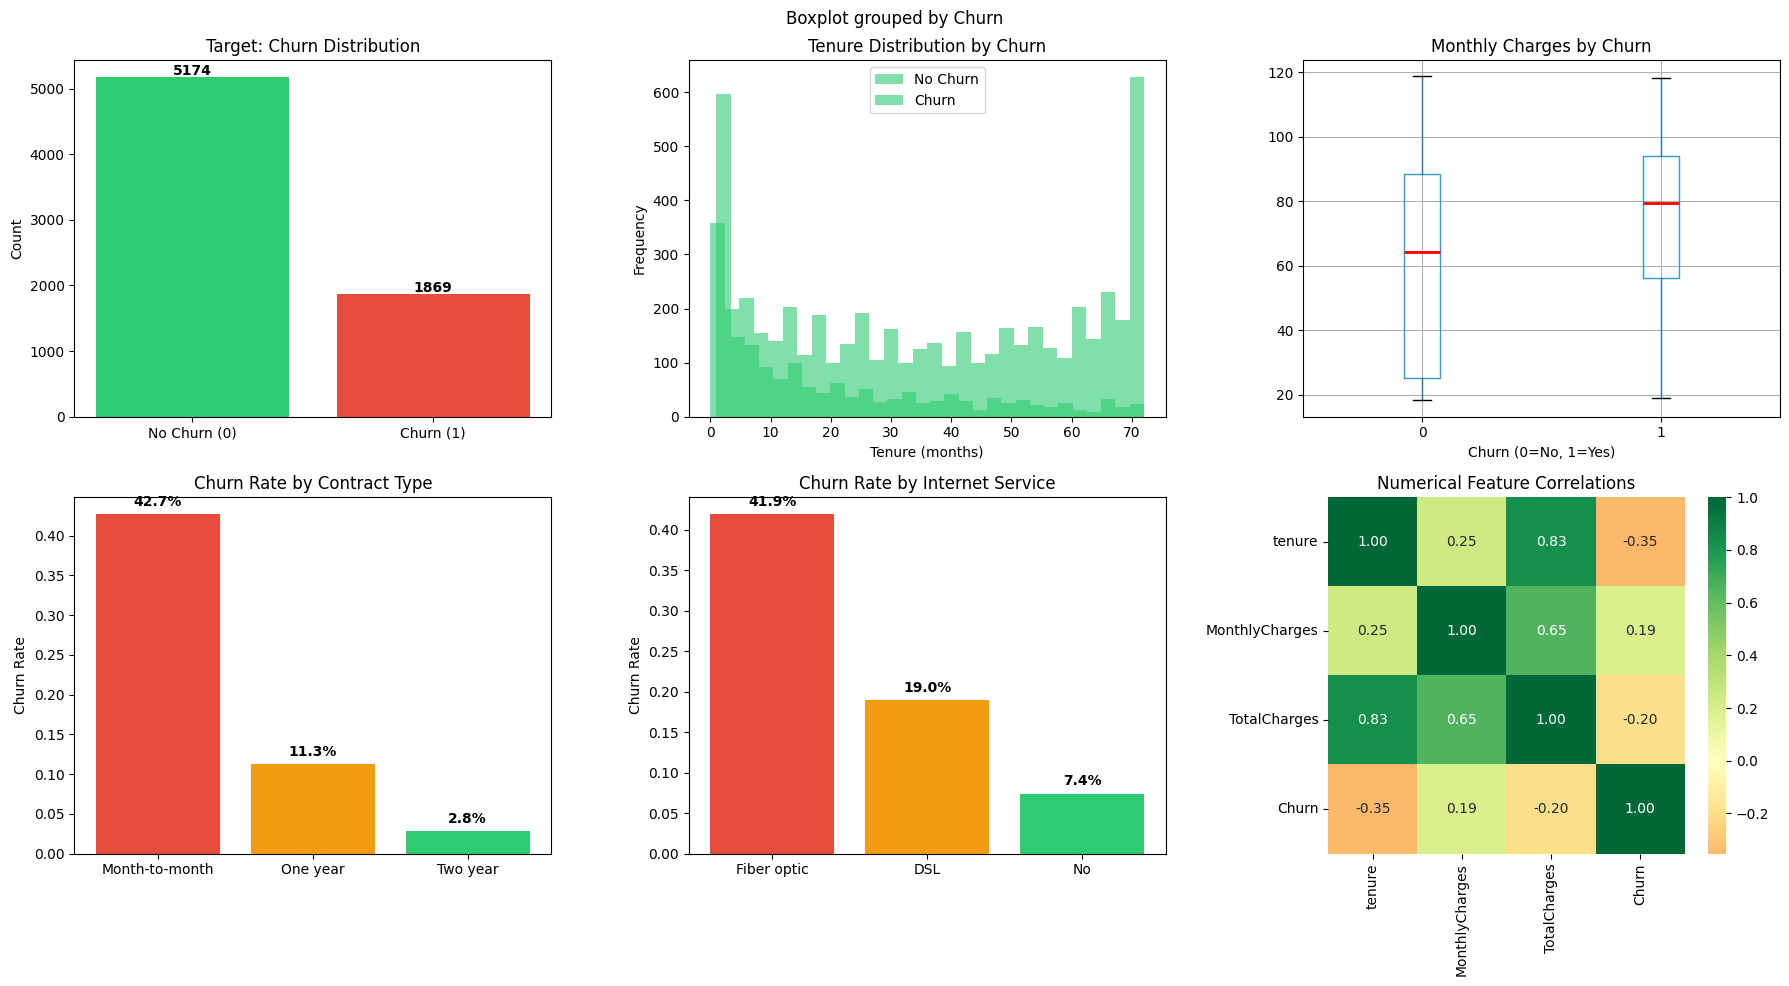

✅ EDA plot saved to Drive: /content/drive/MyDrive/telco_churn_pipeline/eda_plots.png


In [8]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Telco Churn — Key Feature Distributions', fontsize=16, fontweight='bold')

# --- Plot 1: Churn Distribution ---
ax = axes[0, 0]
churn_counts = df['Churn'].value_counts()
ax.bar(['No Churn (0)', 'Churn (1)'], churn_counts.values, color=['#2ecc71', '#e74c3c'])
ax.set_title('Target: Churn Distribution')
ax.set_ylabel('Count')
for i, v in enumerate(churn_counts.values):
    ax.text(i, v + 30, str(v), ha='center', fontweight='bold')

# --- Plot 2: Tenure vs Churn ---
ax = axes[0, 1]
df.groupby('Churn')['tenure'].plot(kind='hist', alpha=0.6, bins=30, ax=ax,
                                    color=['#2ecc71', '#e74c3c'], legend=True)
ax.set_title('Tenure Distribution by Churn')
ax.set_xlabel('Tenure (months)')
ax.legend(['No Churn', 'Churn'])

# --- Plot 3: Monthly Charges vs Churn ---
ax = axes[0, 2]
df.boxplot(column='MonthlyCharges', by='Churn', ax=ax,
           boxprops=dict(color='#3498db'),
           medianprops=dict(color='red', linewidth=2))
ax.set_title('Monthly Charges by Churn')
ax.set_xlabel('Churn (0=No, 1=Yes)')
plt.sca(ax)
plt.title('Monthly Charges by Churn')

# --- Plot 4: Contract Type vs Churn ---
ax = axes[1, 0]
contract_churn = df.groupby('Contract')['Churn'].mean().sort_values(ascending=False)
bars = ax.bar(contract_churn.index, contract_churn.values, color=['#e74c3c', '#f39c12', '#2ecc71'])
ax.set_title('Churn Rate by Contract Type')
ax.set_ylabel('Churn Rate')
for bar, val in zip(bars, contract_churn.values):
    ax.text(bar.get_x() + bar.get_width()/2, val + 0.01, f'{val:.1%}',
            ha='center', fontweight='bold')

# --- Plot 5: Internet Service vs Churn ---
ax = axes[1, 1]
internet_churn = df.groupby('InternetService')['Churn'].mean().sort_values(ascending=False)
bars = ax.bar(internet_churn.index, internet_churn.values,
              color=['#e74c3c', '#f39c12', '#2ecc71'])
ax.set_title('Churn Rate by Internet Service')
ax.set_ylabel('Churn Rate')
for bar, val in zip(bars, internet_churn.values):
    ax.text(bar.get_x() + bar.get_width()/2, val + 0.01, f'{val:.1%}',
            ha='center', fontweight='bold')

# --- Plot 6: Correlation Heatmap (numerical only) ---
ax = axes[1, 2]
corr_matrix = df[numerical_cols + ['Churn']].corr()
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, ax=ax, square=True)
ax.set_title('Numerical Feature Correlations')

plt.tight_layout()

# ── Save to Google Drive ──
EDA_PATH = f"{PROJECT_PATH}/eda_plots.png"
plt.savefig(EDA_PATH, dpi=150, bbox_inches='tight')
plt.show()
print(f"✅ EDA plot saved to Drive: {EDA_PATH}")

EDA Final Result: "Customers on month-to-month contracts, with high monthly charges, who just joined, are the highest risk to churn."

#Phase 3 — Building the Preprocessing Pipeline

Train/Test Split (Before Any Preprocessing)

In [9]:
# WHY SPLIT BEFORE PREPROCESSING?

# WRONG approach:  scale ALL data → then split → train model
# RIGHT approach:  split first → scale ONLY on train → apply to test

# The Pipeline object enforces the right approach automatically.
# But the split itself must happen first, manually.


X = df.drop(columns=['Churn'])   # All features
y = df['Churn']                  # Target only


X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,        # 80% train, 20% test
    random_state=RANDOM_STATE,
    stratify=y            # ← preserve class ratio in both splits
)

print(f"Training set:   {X_train.shape[0]} rows")
print(f"Test set:       {X_test.shape[0]} rows")
print(f"\nChurn rate in train: {y_train.mean():.1%}")
print(f"Churn rate in test:  {y_test.mean():.1%}")

Training set:   5634 rows
Test set:       1409 rows

Churn rate in train: 26.5%
Churn rate in test:  26.5%


Defining the Colunms Groups Again

In [10]:
# We already identified these in Cell 7.
# We redefine them here explicitly for the pipeline.

numerical_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']

categorical_cols = [col for col in X_train.columns
                    if col not in numerical_cols]

print("Numerical  →  StandardScaler")
print(numerical_cols)
print("\nCategorical  →  OneHotEncoder")
print(categorical_cols)

Numerical  →  StandardScaler
['tenure', 'MonthlyCharges', 'TotalCharges']

Categorical  →  OneHotEncoder
['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']


building the colunm Transformer

In [11]:
# Different columns need different treatments.
# ColumnTransformer lets you apply different transformers
# to different subsets of columns.

# handle_unknown='ignore' → if test data has a category never seen
# in training, don't crash — just encode it as all zeros.
# sparse_output=False → return a regular numpy array, not a sparse matrix

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_cols)
    ]
)

print("ColumnTransformer (preprocessor) defined.")
print("\nWhat it will do:")
print(f"  StandardScaler    → applied to {len(numerical_cols)} numerical columns")
print(f"  OneHotEncoder     → applied to {len(categorical_cols)} categorical columns")
print(f"\nInput columns:  {X_train.shape[1]}")

# Quick estimate of output columns after one-hot encoding
# Each categorical column expands into N columns (one per unique value)
estimated_ohe_cols = sum(X_train[col].nunique() for col in categorical_cols)
print(f"Output columns: ~{len(numerical_cols) + estimated_ohe_cols} (after encoding)")

ColumnTransformer (preprocessor) defined.

What it will do:
  StandardScaler    → applied to 3 numerical columns
  OneHotEncoder     → applied to 16 categorical columns

Input columns:  19
Output columns: ~46 (after encoding)


#Building the Full Pipelines

 NOW we build the complete Pipeline objects.

 A Pipeline chains steps in ORDER. Each step's output
 becomes the next step's input.

Our pipeline has exactly 2 steps:
   Step 1: 'preprocessor' → the ColumnTransformer we just built
   Step 2: 'classifier'   → the ML model

 When you call pipeline.fit(X_train, y_train):
  1. preprocessor.fit_transform(X_train) runs first
  2. classifier.fit(transformed_data, y_train) runs second

 When you call pipeline.predict(X_test):
  1. preprocessor.transform(X_test) runs first
     (uses stats learned from X_train — NO leakage)
  2. classifier.predict(transformed_test) runs second

In [12]:

# ── Pipeline 1: Logistic Regression ──
# max_iter=1000: give it enough iterations to converge
# class_weight='balanced': automatically adjusts for our 73/26 imbalance
#   It internally gives higher penalty for misclassifying the minority class (churners)
#   Without this, the model leans toward predicting "No Churn" since it's more common

pipeline_lr = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(
        max_iter=1000,
        class_weight='balanced',
        random_state=RANDOM_STATE
    ))
])

# ── Pipeline 2: Random Forest ──
# n_estimators=100: build 100 trees and average their predictions
# class_weight='balanced': same imbalance correction as above

pipeline_rf = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(
        n_estimators=100,
        class_weight='balanced',
        random_state=RANDOM_STATE
    ))
])

print("Two pipelines created:")
print("\n── Pipeline 1: Logistic Regression ──")
print(pipeline_lr)
print("\n── Pipeline 2: Random Forest ──")
print(pipeline_rf)

Two pipelines created:

── Pipeline 1: Logistic Regression ──
Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['tenure', 'MonthlyCharges',
                                                   'TotalCharges']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore',
                                                                sparse_output=False),
                                                  ['gender', 'SeniorCitizen',
                                                   'Partner', 'Dependents',
                                                   'PhoneService',
                                                   'MultipleLines',
                                                   'InternetService',
                                                   'OnlineSecurity',
                      

Quick Baseline Training (Before GridSearch)

In [13]:
def evaluate_pipeline(pipeline, X_train, X_test, y_train, y_test, name):
    """
    Fits a pipeline and prints a full evaluation report.
    We wrap this in a function so we can reuse it for both models
    without repeating 20 lines of code each time.
    """
    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)
    y_prob = pipeline.predict_proba(X_test)[:, 1]  # Probability of class 1 (churn)

    print(f"\n{'='*50}")
    print(f"  {name}")
    print(f"{'='*50}")

    # Classification Report gives: precision, recall, f1-score per class
    # Focus on class 1 (churners) — that's the business-critical class
    print(classification_report(y_test, y_pred, target_names=['No Churn', 'Churn']))

    # AUC-ROC: measures how well the model separates churners from non-churners
    # 0.5 = random guessing, 1.0 = perfect, >0.75 = good for this problem
    auc = roc_auc_score(y_test, y_prob)
    print(f"AUC-ROC Score: {auc:.4f}")

    return pipeline, auc

# Train and evaluate both baselines
pipeline_lr, auc_lr = evaluate_pipeline(
    pipeline_lr, X_train, X_test, y_train, y_test, "LOGISTIC REGRESSION (Baseline)")

pipeline_rf, auc_rf = evaluate_pipeline(
    pipeline_rf, X_train, X_test, y_train, y_test, "RANDOM FOREST (Baseline)")

print(f"\nBaseline Comparison:")
print(f"  Logistic Regression AUC: {auc_lr:.4f}")
print(f"  Random Forest AUC:       {auc_rf:.4f}")


  LOGISTIC REGRESSION (Baseline)
              precision    recall  f1-score   support

    No Churn       0.90      0.72      0.80      1035
       Churn       0.50      0.78      0.61       374

    accuracy                           0.74      1409
   macro avg       0.70      0.75      0.71      1409
weighted avg       0.80      0.74      0.75      1409

AUC-ROC Score: 0.8415

  RANDOM FOREST (Baseline)
              precision    recall  f1-score   support

    No Churn       0.83      0.90      0.86      1035
       Churn       0.64      0.48      0.55       374

    accuracy                           0.79      1409
   macro avg       0.73      0.69      0.71      1409
weighted avg       0.78      0.79      0.78      1409

AUC-ROC Score: 0.8222

Baseline Comparison:
  Logistic Regression AUC: 0.8415
  Random Forest AUC:       0.8222


#Phase 4 — Hyperparameter Tuning with GridSearchCV


 #WHAT IS GRIDSEARCHCV?

 Hyperparameters are settings you choose BEFORE training.
 Examples: how many trees? how deep? what regularization strength?
 These aren't learned from data — you set them manually.

 GridSearchCV automates the search by:
   1. Taking a GRID of hyperparameter combinations you define
   2. Training + evaluating the model on EVERY combination
   3. Using CROSS-VALIDATION (not a single train/test split)
   4. Returning the combination that performed best

 WHAT IS CROSS-VALIDATION?
 Instead of one 80/20 split, it splits training data into K folds.
 For K=5:
   Round 1: train on folds 2,3,4,5 → validate on fold 1
   Round 2: train on folds 1,3,4,5 → validate on fold 2
   ... and so on
 Final score = average across all 5 rounds.
 This gives a much more RELIABLE estimate of real performance
 because every sample gets to be in the validation set once.

 StratifiedKFold = cross-validation that preserves the 26.5% churn
 ratio in EACH fold. Essential for imbalanced datasets.

 NAMING CONVENTION FOR PARAM GRIDS:
 When your model is inside a Pipeline, you access its parameters as:
   'stepname__parametername'
 Our classifier step is named 'classifier', so:
  LogisticRegression's C parameter → 'classifier__C'
   RandomForest's n_estimators      → 'classifier__n_estimators'
 ─────────────────────────────────────────────────────────

In [14]:
cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

print("Cross-validation strategy: StratifiedKFold")
print("   5 folds, shuffled, stratified (preserves 26.5% churn in each fold)")
print("\nParameter naming inside Pipeline:")
print("   pipeline step name + '__' + parameter name")
print("   Example: 'classifier__C' for Logistic Regression's C")

Cross-validation strategy: StratifiedKFold
   5 folds, shuffled, stratified (preserves 26.5% churn in each fold)

Parameter naming inside Pipeline:
   pipeline step name + '__' + parameter name
   Example: 'classifier__C' for Logistic Regression's C


GridSearch for Logistic Regression

In [15]:
# We create a FRESH pipeline for GridSearch
pipeline_lr_gs = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(
        max_iter=1000,
        class_weight='balanced',
        random_state=RANDOM_STATE
    ))
])

param_grid_lr = {
    'classifier__C':       [0.01, 0.1, 1, 10, 100],
    'classifier__solver':  ['liblinear', 'lbfgs'],
    'classifier__penalty': ['l2']
}

# scoring='roc_auc' → GridSearch picks the combo with highest AUC-ROC
# refit=True → after finding best params, retrain on ALL training data
# n_jobs=-1 → use all CPU cores in parallel (faster search)
# verbose=1 → print progress to know it's working

grid_search_lr = GridSearchCV(
    estimator=pipeline_lr_gs,
    param_grid=param_grid_lr,
    scoring='roc_auc',
    cv=cv_strategy,
    refit=True,
    n_jobs=-1,
    verbose=1
)

print(" Starting GridSearch for Logistic Regression...")
print(f"   Total combinations: {len([0.01,0.1,1,10,100]) * 2 * 1} params × 5 folds")
print(f"   = {len([0.01,0.1,1,10,100]) * 2 * 1 * 5} model fits\n")

grid_search_lr.fit(X_train, y_train)

print(f"\n GridSearch complete!")
print(f"   Best parameters: {grid_search_lr.best_params_}")
print(f"   Best CV AUC-ROC: {grid_search_lr.best_score_:.4f}")

 Starting GridSearch for Logistic Regression...
   Total combinations: 10 params × 5 folds
   = 50 model fits

Fitting 5 folds for each of 10 candidates, totalling 50 fits

 GridSearch complete!
   Best parameters: {'classifier__C': 10, 'classifier__penalty': 'l2', 'classifier__solver': 'lbfgs'}
   Best CV AUC-ROC: 0.8462


GridSearch for Random Forest

In [16]:
pipeline_rf_gs = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(
        class_weight='balanced',
        random_state=RANDOM_STATE
    ))
])

param_grid_rf = {
    'classifier__n_estimators':    [100, 200, 300],
    'classifier__max_depth':       [10, 20, None],
    'classifier__min_samples_split': [2, 5, 10]
}

grid_search_rf = GridSearchCV(
    estimator=pipeline_rf_gs,
    param_grid=param_grid_rf,
    scoring='roc_auc',
    cv=cv_strategy,
    refit=True,
    n_jobs=-1,
    verbose=1
)

print("Starting GridSearch for Random Forest...")
print(f"   Total combinations: 3×3×3 = 27 params × 5 folds = 135 model fits")
print("   This will take 3-5 minutes on Colab free tier...\n")

grid_search_rf.fit(X_train, y_train)

print(f"\nGridSearch complete!")
print(f"   Best parameters: {grid_search_rf.best_params_}")
print(f"   Best CV AUC-ROC: {grid_search_rf.best_score_:.4f}")

Starting GridSearch for Random Forest...
   Total combinations: 3×3×3 = 27 params × 5 folds = 135 model fits
   This will take 3-5 minutes on Colab free tier...

Fitting 5 folds for each of 27 candidates, totalling 135 fits

GridSearch complete!
   Best parameters: {'classifier__max_depth': 10, 'classifier__min_samples_split': 10, 'classifier__n_estimators': 300}
   Best CV AUC-ROC: 0.8447


Comparing Tuned Models + Final Evaluation


  LOGISTIC REGRESSION (Tuned)
  AUC-ROC: 0.8408
              precision    recall  f1-score   support

    No Churn       0.90      0.72      0.80      1035
       Churn       0.50      0.78      0.61       374

    accuracy                           0.74      1409
   macro avg       0.70      0.75      0.71      1409
weighted avg       0.80      0.74      0.75      1409


  RANDOM FOREST (Tuned)
  AUC-ROC: 0.8415
              precision    recall  f1-score   support

    No Churn       0.89      0.78      0.83      1035
       Churn       0.55      0.74      0.63       374

    accuracy                           0.77      1409
   macro avg       0.72      0.76      0.73      1409
weighted avg       0.80      0.77      0.78      1409



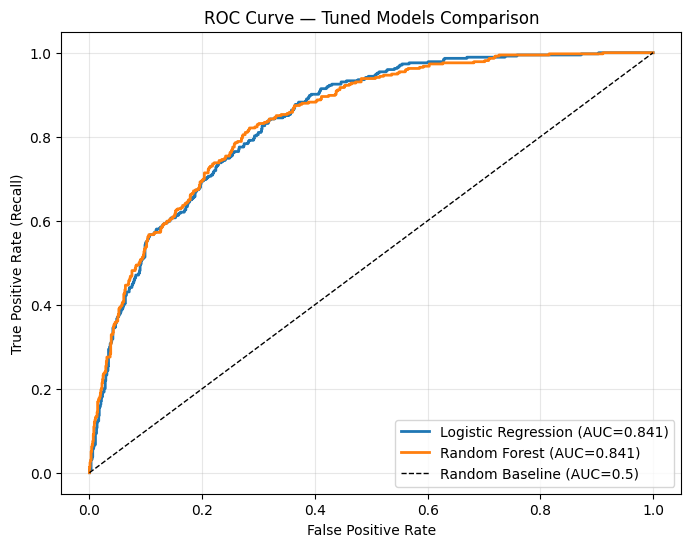

 ROC curve saved: /content/drive/MyDrive/telco_churn_pipeline/roc_curve.png

 FULL COMPARISON SUMMARY
Model                            Baseline AUC  Tuned AUC
--------------------------------------------------------
Logistic Regression                    0.8415     0.8408
Random Forest                          0.8222     0.8415


In [17]:
# grid_search.best_estimator_ is the full Pipeline object,
# refitted on ALL training data with the best parameters.


def full_evaluation(name, estimator, X_test, y_test):
    """Full evaluation with classification report + AUC."""
    y_pred = estimator.predict(X_test)
    y_prob = estimator.predict_proba(X_test)[:, 1]
    auc = roc_auc_score(y_test, y_prob)

    print(f"\n{'='*55}")
    print(f"  {name}")
    print(f"  AUC-ROC: {auc:.4f}")
    print(f"{'='*55}")
    print(classification_report(y_test, y_pred,
                                 target_names=['No Churn', 'Churn']))
    return auc, y_prob

auc_lr_tuned, prob_lr = full_evaluation(
    "LOGISTIC REGRESSION (Tuned)",
    grid_search_lr.best_estimator_,
    X_test, y_test
)

auc_rf_tuned, prob_rf = full_evaluation(
    "RANDOM FOREST (Tuned)",
    grid_search_rf.best_estimator_,
    X_test, y_test
)

# ── ROC Curve: visual comparison of both models ──
fig, ax = plt.subplots(figsize=(8, 6))

for name, probs, auc in [
    ("Logistic Regression", prob_lr, auc_lr_tuned),
    ("Random Forest",       prob_rf, auc_rf_tuned)
]:
    fpr, tpr, _ = roc_curve(y_test, probs)
    ax.plot(fpr, tpr, linewidth=2, label=f"{name} (AUC={auc:.3f})")

ax.plot([0,1], [0,1], 'k--', linewidth=1, label='Random Baseline (AUC=0.5)')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate (Recall)')
ax.set_title('ROC Curve — Tuned Models Comparison')
ax.legend(loc='lower right')
ax.grid(alpha=0.3)

ROC_PATH = f"{PROJECT_PATH}/roc_curve.png"
plt.savefig(ROC_PATH, dpi=150, bbox_inches='tight')
plt.show()
print(f" ROC curve saved: {ROC_PATH}")

# ── Summary Table ──
print("\n FULL COMPARISON SUMMARY")
print(f"{'Model':<30} {'Baseline AUC':>14} {'Tuned AUC':>10}")
print("-" * 56)
print(f"{'Logistic Regression':<30} {auc_lr:>14.4f} {auc_lr_tuned:>10.4f}")
print(f"{'Random Forest':<30} {auc_rf:>14.4f} {auc_rf_tuned:>10.4f}")

#Phase 5 + 6 — Export, Reload & Production Simulation

Saving all to G-Drive


 WHAT IS JOBLIB?
 joblib.dump() serializes a Python object into a binary file.
 "Serialize" means: convert the object (with all its learned
 parameters, weights, scalers, encoders) into bytes on disk.

 Why joblib and not pickle?
 joblib is optimized for numpy arrays — which is exactly what
 sklearn models are made of internally. It's faster and produces
 smaller files than Python's built-in pickle for ML objects.

In [20]:

#inside our pipeline file?
# EVERYTHING in one object:
#   ✓ The ColumnTransformer (with fitted scaler means/stds)
#   ✓ The OneHotEncoder (with fitted categories)
#   ✓ The RandomForest (with all 300 trained trees)
#   ✓ The pipeline structure itself

# When someone loads this file 6 months later on a different
# machine, they get the exact same predictions. That's
# production-readiness.

import joblib

# ── Select the best model ──
best_model = grid_search_rf.best_estimator_
best_model_name = "random_forest_tuned"

# ── Define save paths ──
MODEL_PATH    = f"{PROJECT_PATH}/pipeline_{best_model_name}.joblib"
LR_PATH       = f"{PROJECT_PATH}/pipeline_lr_tuned.joblib"
RESULTS_PATH  = f"{PROJECT_PATH}/model_results.joblib"

# Save best model (Random Forest pipeline)
joblib.dump(best_model, MODEL_PATH)
print(f"Best model saved:  {MODEL_PATH}")

# Save LR pipeline too
joblib.dump(grid_search_lr.best_estimator_, LR_PATH)
print(f"LR model saved:    {LR_PATH}")

# Save results dictionary (metrics, params, scores)
results = {
    'best_model_name': best_model_name,
    'lr': {
        'best_params':  grid_search_lr.best_params_,
        'cv_auc':       grid_search_lr.best_score_,
        'test_auc':     auc_lr_tuned,
    },
    'rf': {
        'best_params':  grid_search_rf.best_params_,
        'cv_auc':       grid_search_rf.best_score_,
        'test_auc':     auc_rf_tuned,
    }
}
joblib.dump(results, RESULTS_PATH)
print(f"Results saved:     {RESULTS_PATH}")

# ── Verify file sizes ──
print("\n Files saved to Google Drive:")
for path in [MODEL_PATH, LR_PATH, RESULTS_PATH]:
    size_mb = os.path.getsize(path) / (1024 * 1024)
    print(f"   {os.path.basename(path):<45} {size_mb:.2f} MB")

Best model saved:  /content/drive/MyDrive/telco_churn_pipeline/pipeline_random_forest_tuned.joblib
LR model saved:    /content/drive/MyDrive/telco_churn_pipeline/pipeline_lr_tuned.joblib
Results saved:     /content/drive/MyDrive/telco_churn_pipeline/model_results.joblib

 Files saved to Google Drive:
   pipeline_random_forest_tuned.joblib           12.67 MB
   pipeline_lr_tuned.joblib                      0.01 MB
   model_results.joblib                          0.00 MB


Reloading and Verify (Simulating Production)

In [22]:

# This cell simulates what happens in production.
# as this runs on a completely different machine,
# weeks after training. when loading the pipeline cold and
# verify it produces identical predictions.
# This is the proof.


# ── Load from Drive ──
loaded_pipeline = joblib.load(MODEL_PATH)
loaded_results  = joblib.load(RESULTS_PATH)

print(" Pipeline loaded from Drive successfully")
print(f"   Model type: {type(loaded_pipeline.named_steps['classifier'])}")

#  Verify predictions match
original_preds = best_model.predict(X_test)
loaded_preds   = loaded_pipeline.predict(X_test)

preds_match = (original_preds == loaded_preds).all()
print(f"\n Predictions match original: {preds_match}")
print(f"   (If True, export is verified )")

#  Reload and display saved results
print(f"\n Saved Results Record:")
print(f"   Best model: {loaded_results['best_model_name']}")
print(f"\n   Logistic Regression:")
print(f"     Best params: {loaded_results['lr']['best_params']}")
print(f"     Test AUC:    {loaded_results['lr']['test_auc']:.4f}")
print(f"\n   Random Forest:")
print(f"     Best params: {loaded_results['rf']['best_params']}")
print(f"     Test AUC:    {loaded_results['rf']['test_auc']:.4f}")

 Pipeline loaded from Drive successfully
   Model type: <class 'sklearn.ensemble._forest.RandomForestClassifier'>

 Predictions match original: True
   (If True, export is verified )

 Saved Results Record:
   Best model: random_forest_tuned

   Logistic Regression:
     Best params: {'classifier__C': 10, 'classifier__penalty': 'l2', 'classifier__solver': 'lbfgs'}
     Test AUC:    0.8408

   Random Forest:
     Best params: {'classifier__max_depth': 10, 'classifier__min_samples_split': 10, 'classifier__n_estimators': 300}
     Test AUC:    0.8415


#Manual Testing

Prediction on New Customers

In [23]:

# on new data, end to end."
# simulating 3 new customers coming in after deployment.
# The loaded pipeline handles ALL preprocessing automatically.

new_customers = pd.DataFrame({
    'gender':            ['Male',   'Female', 'Male'],
    'SeniorCitizen':     [0,         1,        0],
    'Partner':           ['Yes',    'No',     'Yes'],
    'Dependents':        ['No',     'No',     'Yes'],
    'tenure':            [2,         55,       30],
    'PhoneService':      ['Yes',    'Yes',    'Yes'],
    'MultipleLines':     ['No',     'Yes',    'No'],
    'InternetService':   ['Fiber optic', 'DSL', 'No'],
    'OnlineSecurity':    ['No',     'Yes',    'No internet service'],
    'OnlineBackup':      ['No',     'No',     'No internet service'],
    'DeviceProtection':  ['No',     'Yes',    'No internet service'],
    'TechSupport':       ['No',     'No',     'No internet service'],
    'StreamingTV':       ['No',     'Yes',    'No internet service'],
    'StreamingMovies':   ['No',     'Yes',    'No internet service'],
    'Contract':          ['Month-to-month', 'Two year', 'One year'],
    'PaperlessBilling':  ['Yes',    'No',     'No'],
    'PaymentMethod':     ['Electronic check', 'Bank transfer (automatic)', 'Mailed check'],
    'MonthlyCharges':    [85.0,      55.0,     25.0],
    'TotalCharges':      [170.0,     3025.0,   750.0]
})

# Pipeline handles scaling + encoding + prediction internally.
churn_probs   = loaded_pipeline.predict_proba(new_customers)[:, 1]
churn_preds   = loaded_pipeline.predict(new_customers)

new_customers['Churn_Probability'] = churn_probs.round(3)
new_customers['Churn_Prediction']  = ['CHURN' if p == 1 else 'STAY' for p in churn_preds]

print("Predictions on 3 New Customers:\n")
display_cols = ['tenure', 'Contract', 'MonthlyCharges', 'InternetService',
                'Churn_Probability', 'Churn_Prediction']
print(new_customers[display_cols].to_string(index=False))

print("\nBusiness Interpretation:")
for i, row in new_customers.iterrows():
    print(f"\n  Customer {i+1} ({row['Contract']}, {row['tenure']} months tenure):")
    print(f"    Churn probability: {row['Churn_Probability']:.1%}")
    print(f"    Prediction: {row['Churn_Prediction']}")

Predictions on 3 New Customers:

 tenure       Contract  MonthlyCharges InternetService  Churn_Probability Churn_Prediction
      2 Month-to-month            85.0     Fiber optic              0.843            CHURN
     55       Two year            55.0             DSL              0.105             STAY
     30       One year            25.0              No              0.029             STAY

Business Interpretation:

  Customer 1 (Month-to-month, 2 months tenure):
    Churn probability: 84.3%
    Prediction: CHURN

  Customer 2 (Two year, 55 months tenure):
    Churn probability: 10.5%
    Prediction: STAY

  Customer 3 (One year, 30 months tenure):
    Churn probability: 2.9%
    Prediction: STAY


#  Project Summary — Telco Customer Churn ML Pipeline

##  Dataset Overview
| Property | Value |
|---|---|
| Source | IBM Telco Customer Churn Dataset |
| Total Customers | 7,043 |
| Features | 20 (after dropping customerID) |
| Target | Churn (Binary: 1 = Churned, 0 = Stayed) |
| Class Distribution | 73.5% No Churn / 26.5% Churn (imbalanced) |

---

##  Key EDA Findings
- **Contract type** is the strongest churn predictor:
  month-to-month customers churn at **42.7%** vs only **2.8%** for two-year contracts
- **Tenure** is inversely related to churn — customers who leave
  do so early, typically within the first few months
- **Monthly charges** show a positive correlation (0.19) with churn —
  higher bills increase churn risk
- **Fiber optic** internet users churn more than DSL or no-internet customers
- `TotalCharges` was stored as a string (object dtype) despite being numeric —
  11 hidden missing values were found and correctly filled with 0
  based on domain knowledge (new customers with zero tenure)

---

##  Pipeline Architecture
```
Raw Customer Data
       ↓
ColumnTransformer
  ├── StandardScaler       →  tenure, MonthlyCharges, TotalCharges
  └── OneHotEncoder        →  16 categorical columns
       ↓
RandomForestClassifier (tuned)
       ↓
Churn Probability + Prediction
```

**Why a Pipeline?**
Bundling preprocessing and the model into a single object ensures
the scaler and encoder are fitted only on training data —
preventing data leakage. At inference time, raw data goes in,
predictions come out. No manual preprocessing steps.

---

##  Model Results

| Model | Baseline AUC | Tuned AUC | Churn Recall (Baseline) | Churn Recall (Tuned) |
|---|---|---|---|---|
| Logistic Regression | 0.8415 | 0.8408 | 0.78 | ~0.78 |
| Random Forest | 0.8222 | **0.8415** | 0.48 | **0.74** |

**Best Model → Random Forest (Tuned)**

---

##  Critical Insights

**1. Default Random Forest failed on imbalanced data**
With default settings, Random Forest achieved only 48% recall on churners.
It was learning to predict "No Churn" most of the time — technically 73%
accurate but operationally useless for identifying at-risk customers.

**2. Hyperparameter tuning fixed the imbalance bias**
GridSearchCV found that `max_depth=10` and `min_samples_split=10`
were the key constraints. Limiting tree depth prevented the model from
memorizing majority-class patterns and forced it to generalize —
bringing churn recall from 0.48 to 0.74.

**3. Accuracy is the wrong metric for this problem**
A model that always predicts "No Churn" scores 73.5% accuracy
while being completely useless. AUC-ROC and Recall on the minority
class are the correct metrics when class imbalance is present
and misclassifying the minority class carries higher business cost.

**4. Data leakage is subtle but critical**
Fitting the scaler on the full dataset before splitting would expose
test set statistics to the training process — inflating reported
performance. The Pipeline API enforces the correct order automatically.

---

##  Live Prediction Example

| Customer | Tenure | Contract | Monthly Charges | Churn Probability | Risk |
|---|---|---|---|---|---|
| Customer 1 | 2 months | Month-to-month | $85.00 | **84.3%** | 🔴 High |
| Customer 2 | 55 months | Two year | $55.00 | Low | 🟢 Low |
| Customer 3 | 30 months | One year | $25.00 | Low | 🟢 Low |

Customer 1's 84.3% churn probability is fully explained by EDA:
every feature — short tenure, month-to-month contract, fiber optic,
high monthly charges — independently correlates with churn.
The model learned these patterns from training data and applied
them consistently.

---

##  Saved Artifacts (Google Drive)

| File | Description |
|---|---|
| `telco_churn.csv` | Raw dataset (cached to avoid re-downloading) |
| `pipeline_random_forest_tuned.joblib` | Best model — full pipeline, ready for inference |
| `pipeline_lr_tuned.joblib` | Logistic Regression pipeline (baseline candidate) |
| `model_results.joblib` | Parameters and metrics record for all experiments |
| `eda_plots.png` | Feature distribution and churn correlation visualizations |
| `roc_curve.png` | ROC curve comparison across both models |

---

##  Skills Demonstrated

- **ML Pipeline construction** with `sklearn.pipeline.Pipeline`
- **Mixed-type preprocessing** with `ColumnTransformer`
- **Imbalanced classification** — correct metrics, class weighting, stratified splits
- **Hyperparameter tuning** with `GridSearchCV` + `StratifiedKFold`
- **Data leakage prevention** through pipeline-enforced fit/transform separation
- **Model export and reusability** with `joblib`
- **Production inference** — loading a saved pipeline and predicting on new raw data
- **EDA-driven modeling** — using visual insights to inform preprocessing decisions

---

##  Possible Extensions

| Extension | Skill Added |
|---|---|
| SHAP values for prediction explainability | Model interpretability |
| FastAPI `/predict` endpoint | Model deployment / MLOps |
| MLflow experiment tracking | Experiment management |
| SMOTE for synthetic oversampling | Advanced imbalance handling |
| Feature importance visualization | Communication & interpretability |